# PREPARATION

In [2]:
import pandas as pd
import numpy as np
import heapq
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('df_analyse_amont.csv')

/var/folders/nj/df5chzfs36x14c6y_q7pdbh80000gn/T/ipykernel_87829/684265032.py:1: DtypeWarning: Columns (11,12,14,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('df_analyse_amont.csv')


In [4]:
!pip3 install openpyxl

In [5]:
chemin = 'BD_2016_2020_TableauDynamique.xlsx'
df_original = pd.read_excel(chemin, sheet_name="Extraction juin 2016 juin 2020")

In [6]:
df_copy = df_original.copy()

In [7]:
df_original.columns

Index(['Num d'ordre', 'Date', 'Heure',
       ' Informations du passage->date et heure d'arrivée',
       ' Informations du passage->moyen d'arrivée', ' IAO->motif d'entrée',
       ' IAO->motif de venue', ' Patient->age en année',
       ' Antécédent->antécédents médicaux',
       ' Antécédent->antécédents chirurgicaux',
       ' Constante->Surveillances->PAS/PAD adultes (première valeur)',
       ' Constante->Surveillances->FC adultes (première valeur)',
       ' Constante->Surveillances->Température adultes (première valeur)',
       ' Constante->Surveillances->SaO2 adultes (première valeur)',
       ' Constante->Surveillances->Fréquence Respiratoire (première valeur)',
       ' Diagnostic->Code CCMU', ' Localisation->Salles',
       ' Localisation->date d'entrée en box', ' Anamnèse->texte',
       ' IAO->observation',
       ' Examens complémentaires->a des examens de biologie',
       ' Examens complémentaires->a des examens de radiologie',
       ' Examens complémentaires->a des 

In [8]:
df_copy[" Informations du passage->date début prise en charge médicale"]

0         42522.043750
1         42522.093056
2                  NaN
3         42522.081250
4         42522.107639
              ...     
336248    43984.075694
336249             NaN
336250    43984.128472
336251    43984.140972
336252             NaN
Name:  Informations du passage->date début prise en charge médicale, Length: 336253, dtype: float64

In [9]:
cols = [
    " Informations du passage->date début prise en charge médicale",
    " Examens complémentaires->date et heure de première prescription de biologie"
]

for col in cols:
    df_copy[col] = pd.to_datetime(
        df_copy[col],
        unit="d",
        origin="1899-12-30",
        errors="coerce"
    )

In [10]:
df_copy[[
    " Informations du passage->date début prise en charge médicale",
    " Examens complémentaires->date et heure de première prescription de biologie",
]].dropna().head(15)

,Informations du passage->date début prise en charge médicale,Examens complémentaires->date et heure de première prescription de biologie
0,2016-06-01 01:02:59.999999749,2016-06-01 01:30:00.000000000
1,2016-06-01 02:13:59.999995407,2016-06-01 01:34:00.000002040
3,2016-06-01 01:57:00.000000250,2016-06-01 01:39:59.999996298
4,2016-06-01 02:35:00.000000769,2016-06-01 01:34:00.000002040
6,2016-06-01 02:17:00.000001020,2016-06-01 02:17:00.000001020
7,2016-06-01 02:30:59.999998728,2016-06-01 02:25:59.999992095
8,2016-06-01 02:32:59.999999749,2016-06-01 02:32:59.999999749
10,2016-06-01 02:57:00.000003182,2016-06-01 05:41:00.000003831
11,2016-06-01 02:58:59.999995407,2016-06-01 02:58:59.999995407
12,2016-06-01 04:18:59.999999109,2016-06-01 04:18:59.999999109


In [11]:
df_copy["temps_passe_box_min"] = (
    df_copy[" Informations du passage->date début prise en charge médicale"]
    - df_copy[" Examens complémentaires->date et heure de première prescription de biologie"]
).dt.total_seconds() / 60

In [12]:
df_copy[[
    " Examens complémentaires->date et heure de première prescription de biologie",
    " Orientation->type d'orientation"
]].dropna().head(15)

,Examens complémentaires->date et heure de première prescription de biologie,Orientation->type d'orientation
0,2016-06-01 01:30:00.000000000,RETOUR DOMICILE
1,2016-06-01 01:34:00.000002040,TRANSFERT EXTERNE
3,2016-06-01 01:39:59.999996298,RETOUR DOMICILE
4,2016-06-01 01:34:00.000002040,RETOUR DOMICILE
6,2016-06-01 02:17:00.000001020,RETOUR DOMICILE
7,2016-06-01 02:25:59.999992095,RETOUR DOMICILE
8,2016-06-01 02:32:59.999999749,RETOUR DOMICILE
10,2016-06-01 05:41:00.000003831,RETOUR DOMICILE
11,2016-06-01 02:58:59.999995407,RETOUR DOMICILE
12,2016-06-01 04:18:59.999999109,RETOUR DOMICILE


In [13]:
df_copy["temps_passe_box_min"].head(20)

0     -27.0
1      40.0
2       NaN
3      17.0
4      61.0
5       NaN
6       0.0
7       5.0
8       0.0
9       NaN
10   -164.0
11      0.0
12      0.0
13     18.0
14      NaN
15      NaN
16      NaN
17     38.0
18     -3.0
19     28.0
Name: temps_passe_box_min, dtype: float64

In [14]:
df_original.head()

,Num d'ordre,Date,Heure,Informations du passage->date et heure d'arrivée,Informations du passage->moyen d'arrivée,IAO->motif d'entrée,IAO->motif de venue,Patient->age en année,Antécédent->antécédents médicaux,Antécédent->antécédents chirurgicaux,...,Informations du passage->CAC du séjour,Informations du passage->date et heure de sortie,Informations du passage->date début prise en charge médicale,Informations du passage->dossier dans l'hôpital,Orientation->type d'orientation,Orientation->destination,Orientation->tansfert vers le service,Orientation->transfert vers l'hôpital,Patient->code postal de la ville,Patient->nom de la ville
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,...,3093.0,42522.176389,42522.043750,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59139,WATTIGNIES
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,...,3102.0,42522.461806,42522.093056,NaN,TRANSFERT EXTERNE,Transfert CLINIQUE DUBOIS (LILLE) Motif: Conve...,NaN,CLINIQUE DUBOIS,59310,ORCHIES
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,...,3102.0,42522.127778,NaN,NaN,TRANSFERT INTERNE,Admis(e) en NEUROLOGIE B 5 EST (3281/CAC),NEUROLOGIE B 5 EST,NaN,59480,LA BASSEE
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,...,3093.0,42522.201389,42522.081250,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59136,WAVRIN
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,...,3102.0,42522.663194,42522.107639,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59130,LAMBERSART


In [15]:
df.head()

,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,...,is_retour_domicile,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,...,1,0,0,47.0,50.0,0.118129,-1.090800,1.308571,-1.855631,-0.624738
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,...,0,1,0,116.0,74.0,2.192266,0.107738,-1.414844,-1.254767,-1.074449
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,...,0,1,0,NaN,5.0,0.096306,-0.465269,-2.492932,-1.216424,1.195746
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,...,1,0,0,74.0,53.0,-1.001173,0.115672,0.395099,-0.513320,-0.695704
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,...,1,0,0,79.0,20.0,-0.000047,0.384547,0.760444,-1.609653,1.700027


In [16]:
df["_informations_du_passage_date_dbut_prise_en_charge_mdicale_dt"].head()

0    2016-06-01 01:02:59.999999749
1    2016-06-01 02:13:59.999995407
2                              NaN
3    2016-06-01 01:57:00.000000250
4    2016-06-01 02:35:00.000000769
Name: _informations_du_passage_date_dbut_prise_en_charge_mdicale_dt, dtype: object

In [17]:
df["datetime_arrivee"].head()

0    2016-06-01 00:16:00
1    2016-06-01 00:18:00
2    2016-06-01 00:36:00
3    2016-06-01 00:43:00
4    2016-06-01 01:16:00
Name: datetime_arrivee, dtype: object

In [18]:
df["datetime_sortie"].head()

0    2016-06-01 04:14:00.000001271
1    2016-06-01 11:05:00.000003701
2    2016-06-01 03:04:00.000002040
3    2016-06-01 04:50:00.000000769
4    2016-06-01 15:54:59.999996298
Name: datetime_sortie, dtype: object

In [19]:
df["delai_total_calc"].head()

0    238.0
1    647.0
2    148.0
3    247.0
4    879.0
Name: delai_total_calc, dtype: float64

In [20]:
df["_localisation_date_dentre_en_box_dt"].head()

0    2016-06-01 01:05:59.999997189
1    2016-06-01 01:32:00.000001020
2    2016-06-01 00:40:59.999997959
3    2016-06-01 01:36:00.000003061
4    2016-06-01 01:36:00.000003061
Name: _localisation_date_dentre_en_box_dt, dtype: object

In [21]:
df["delai_arrivee_box_cap"].head()

0    50.0
1    74.0
2     5.0
3    53.0
4    20.0
Name: delai_arrivee_box_cap, dtype: float64

In [22]:
(df["_informations_du_passage_date_et_heure_darrive"] == df["datetime_arrivee"]).value_counts()

True    336253
Name: count, dtype: int64

In [23]:
df["datetime_arrivee"].head()

0    2016-06-01 00:16:00
1    2016-06-01 00:18:00
2    2016-06-01 00:36:00
3    2016-06-01 00:43:00
4    2016-06-01 01:16:00
Name: datetime_arrivee, dtype: object

In [24]:
df['delai_arrivee_box'].head()

0    50.0
1    74.0
2     5.0
3    53.0
4    20.0
Name: delai_arrivee_box, dtype: float64

In [25]:
df["delai_arrivee_PEC_cap"].head(15)

0      47.0
1     116.0
2       NaN
3      74.0
4      79.0
5     100.0
6      47.0
7      48.0
8      48.0
9      31.0
10     33.0
11     32.0
12     50.0
13     55.0
14     18.0
Name: delai_arrivee_PEC_cap, dtype: float64

# PREMIERS ALGOS D'ORDONNANCEMENT

### Algorithme - tri par ordre d'arrivée - FIFO (First In First Out)

* datetime_arrivee : TimeStamp de l'arrivée aux urgences
* delai_arrivee_box_cap : tamps d'attente avant d'entrer dans le box (_localisation_date_dentre_en_box_dt - datetime_arrivee)
* _localisation_date_dentre_en_box_dt : TimeStamp de l'entrée dans le box
* _informations_du_passage_date_dbut_prise_en_charge_mdicale_dt : TimeStamp de la PEC
* IL FAUT CRéER  temps passé dans le box = _informations_du_passage_date_dbut_prise_en_charge_mdicale_dt - _localisation_date_dentre_en_box_dt
* datetime_sortie : TimeStamp de la sortie aux urgences
* delai_total_calc : temps en minutes (datetime_sortie - datetime_arrivee) --> temps passé aux urgences (total)

In [26]:
df["_localisation_date_dentre_en_box_dt"].head()

0    2016-06-01 01:05:59.999997189
1    2016-06-01 01:32:00.000001020
2    2016-06-01 00:40:59.999997959
3    2016-06-01 01:36:00.000003061
4    2016-06-01 01:36:00.000003061
Name: _localisation_date_dentre_en_box_dt, dtype: object

In [27]:
df["_informations_du_passage_date_dbut_prise_en_charge_mdicale_dt"].head()

0    2016-06-01 01:02:59.999999749
1    2016-06-01 02:13:59.999995407
2                              NaN
3    2016-06-01 01:57:00.000000250
4    2016-06-01 02:35:00.000000769
Name: _informations_du_passage_date_dbut_prise_en_charge_mdicale_dt, dtype: object

In [28]:
def parse_date(date_str):
    return pd.to_datetime(date_str).normalize()

def parse_time(time_str):
    t = str(time_str).strip().lower().replace("h", ":").replace(" ", "")
    if ":" not in t:
        t = f"{t}:00"
    if len(t.split(":")[0]) == 1:
        t = "0" + t
    return pd.to_datetime(t, format="%H:%M").time()

def build_interval(date_str, start_time_str, end_time_str):
    d = parse_date(date_str)
    t0 = parse_time(start_time_str)
    t1 = parse_time(end_time_str)
    start_dt = pd.Timestamp.combine(d.date(), t0)
    end_dt = pd.Timestamp.combine(d.date(), t1)
    return start_dt, end_dt

def fifo_by_arrival_interval(df_raw, date_str, start_time_str, end_time_str):
    df = df_raw.copy()
    df["datetime_arrivee"] = pd.to_datetime(df["datetime_arrivee"], errors="coerce")
    df = df.dropna(subset=["datetime_arrivee"])

    start_dt, end_dt = build_interval(date_str, start_time_str, end_time_str)

    df = df[(df["datetime_arrivee"] >= start_dt) &
            (df["datetime_arrivee"] < end_dt)]

    df_sorted = df.sort_values("datetime_arrivee").reset_index(drop=True)

    return df_sorted[["num_dordre", "datetime_arrivee"]]

In [29]:
# Exemple
df_fifo = fifo_by_arrival_interval(df, "2016-06-01", "10:00", "11:00")
print(df_fifo)

    num_dordre    datetime_arrivee
0           47 2016-06-01 10:00:00
1           48 2016-06-01 10:22:00
2           49 2016-06-01 10:23:00
3           50 2016-06-01 10:25:00
4           51 2016-06-01 10:30:00
5           52 2016-06-01 10:37:00
6           53 2016-06-01 10:43:00
7           54 2016-06-01 10:46:00
8           55 2016-06-01 10:51:00
9           56 2016-06-01 10:54:00
10          57 2016-06-01 10:55:00


In [30]:
df[df["num_dordre"] == 47].head()

,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,...,is_retour_domicile,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
46,47,2016-06-01,10:00:00,2016-06-01 10:00:00,MOYENS PERSONNELS,0A CC _ AT du 30/05 lombosciatalgie après...,Rhumatologie non traumatique: Lombalgie,59,Apnée du sommeil appareillé RGO,hernie discal L5/S1 en 1996. nucléoplastie L4...,...,1,0,0,24.0,51.0,-0.717514,1.136942,0.734768,-1.449917,1.733312


### Algorithme - tri par niveau de gravité

In [31]:
df._diagnostic_code_ccmu.value_counts()

_diagnostic_code_ccmu
2    229295
1     33293
3     19637
P      6068
4      2864
5      1738
D       227
Name: count, dtype: int64

P = psy
D = décès

--> ordre de priorité de passage : D, 5, 4, 3, 2, 1, P

In [32]:
df[df._diagnostic_code_ccmu == "P"].head(20)

,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,...,is_retour_domicile,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
14,15,2016-06-01,04:16:00,2016-06-01 04:16:00,AMBULANCE PRIVEE,"retrouvé sur VP, patient bipolaire, demande un...",Psychiatrie: Bouffée délirante aigue/délire De...,30,"Patient schizophrène, DNID Notion d'inobserva...",NaN,...,1,0,0,18.0,NaN,-1.579155,-0.441408,0.610856,-1.597380,1.914429
132,133,2016-06-01,15:45:00,2016-06-01 15:45:00,AMBULANCE PRIVEE,sd depressif,Psychiatrie: Anxiété,46,NaN,NaN,...,1,0,0,109.0,NaN,-1.536265,-0.830006,0.062340,0.570880,0.784345
139,140,2016-06-01,16:24:00,2016-06-01 16:24:00,AMBULANCE PRIVEE,"agitation , agressivité","Psychiatrie: Agitation, agressivité",24,Asthme dans l'enfance plusieurs épisodes de p...,NaN,...,0,1,0,22.0,NaN,-0.248106,-0.012709,-2.121285,-0.225400,1.317599
415,416,2016-06-02,21:38:00,2016-06-02 21:38:00,MOYENS PERSONNELS,crise d'angoisse apres une mauvaise nouvelle,Psychiatrie: Anxiété,20,Asthme Crise d'angoisse,NaN,...,1,0,0,62.0,121.0,-1.493373,0.014885,0.523270,0.866309,1.177637
416,417,2016-06-02,21:52:00,2016-06-02 21:52:00,AMBULANCE PRIVEE,angoisse - 1er episode d'hallucinations auditi...,Psychiatrie: Anxiété,19,Aucun,NaN,...,0,1,0,69.0,54.0,0.686190,0.407078,-1.807844,0.481538,1.234125
425,426,2016-06-02,23:08:00,2016-06-02 23:08:00,MOYENS PERSONNELS,detresse psychologique,Psychiatrie: Anxiété,20,NaN,NaN,...,1,0,0,72.0,42.0,-1.923175,-1.193061,0.038533,1.107743,0.699015
439,440,2016-06-03,01:52:00,2016-06-03 01:52:00,AMBULANCE PRIVEE,mouvements incontrolés du MSD depuis hier,NaN,43,Deficience mentale légére,HTIC avec dérivation ventriculo-péritonéale s...,...,1,0,0,41.0,31.0,-0.956910,0.874101,0.974440,-2.175173,2.066613
548,549,2016-06-03,15:25:00,2016-06-03 15:25:00,MOYENS PERSONNELS,trble cmpt + hallucination visuelle transfer...,Psychiatrie: Demande de consultation psychiatr...,32,NaN,NaN,...,0,1,0,54.0,81.0,2.882009,-1.556371,-1.655355,0.809472,0.552993
584,585,2016-06-03,18:25:00,2016-06-03 18:25:00,AMBULANCE PRIVEE,crise de boulimie+ anorexie mentale,Divers: AEG - Altération de l'état généralPsyc...,25,NaN,NaN,...,1,0,0,45.0,31.0,-2.038682,-1.363723,0.092358,0.023217,1.270774
618,619,2016-06-03,20:10:00,2016-06-03 20:10:00,AMBULANCE PRIVEE,syndrôme depressif + idées sucidaires bipola...,Psychiatrie: Idées suicidaires,43,BPCO post tabagique non sevrée Schizophrénie ...,Appendicectomie Fracture de cheville gauche,...,0,1,0,35.0,NaN,0.254030,1.343701,-1.813029,-0.796890,1.915206


In [33]:
df[df._diagnostic_code_ccmu == "D"]._iao_motif_de_venue.size

227

In [34]:
df[df._diagnostic_code_ccmu == "D"]._iao_motif_de_venue.isna().sum()

np.int64(169)

In [35]:
df[df._diagnostic_code_ccmu == "D"]._orientation_type_dorientation.value_counts()

_orientation_type_dorientation
DECES                221
TRANSFERT INTERNE      3
RETOUR DOMICILE        3
Name: count, dtype: int64

In [36]:
df[df._diagnostic_code_ccmu == "D"]._iao_motif_de_venue.value_counts()

_iao_motif_de_venue
Pneumologie: Dyspnée sans détresse                                                                                                         6
Pneumologie: Détresse respiratoire majeure                                                                                                 6
Divers: AEG - Altération de l'état général                                                                                                 4
Gastro-entérologie: Douleur abdominale (patient non valide/nécessitant brancard)                                                           4
Neuro-chirurgie: Transfert SMUR pour prise en charge neurochir => Transfert Déchoc chir                                                    3
Pneumologie: Pneumopathie                                                                                                                  2
Neurologie: Déficit neurologique de moins de 4h30 (appel sénior ou neurologue)                                                        

In [37]:
def prepare_and_filter(df_raw, date_str, start_time_str, end_time_str):
    df = df_raw.copy()
    df["datetime_arrivee"] = pd.to_datetime(df["datetime_arrivee"], errors="coerce")
    df["_diagnostic_code_ccmu"] = df["_diagnostic_code_ccmu"].astype(str).str.strip()
    df = df.dropna(subset=["datetime_arrivee"])

    start_dt, end_dt = build_interval(date_str, start_time_str, end_time_str)
    df = df[(df["datetime_arrivee"] >= start_dt) & (df["datetime_arrivee"] < end_dt)].copy()

    df = df[df["_diagnostic_code_ccmu"].notna()].copy()

    order_map = {"D": 0, "5": 1, "4": 2, "3": 3, "2": 4, "1": 5, "P": 6}
    df["prio_rank"] = df["_diagnostic_code_ccmu"].map(order_map)
    df = df[df["prio_rank"].notna()].copy()

    return df.sort_values("datetime_arrivee").reset_index(drop=True)

def compute_order(df_arrived):
    df_sorted = df_arrived.sort_values(
        ["prio_rank", "datetime_arrivee"],
        ascending=[True, True]
    ).reset_index(drop=True)




















    

    df_sorted["patient_num"] = df_sorted.index + 1
    return df_sorted[["patient_num", "datetime_arrivee", "_diagnostic_code_ccmu"]]

In [38]:
# Exemple :
df_filtered = prepare_and_filter(df, "2016-07-01", "20:00", "22:00")
changes = compute_order(df_filtered)
changes

,patient_num,datetime_arrivee,_diagnostic_code_ccmu
0,1,2016-07-01 21:08:00,5
1,2,2016-07-01 20:07:00,2
2,3,2016-07-01 20:24:00,2
3,4,2016-07-01 20:40:00,2
4,5,2016-07-01 20:42:00,2
5,6,2016-07-01 20:42:00,2
6,7,2016-07-01 20:48:00,2
7,8,2016-07-01 20:51:00,2
8,9,2016-07-01 20:57:00,2
9,10,2016-07-01 21:00:00,2


### Algorithme - tri par durée (SPT)

In [39]:
def parse_date(date_str):
    return pd.to_datetime(date_str).normalize()

def parse_time(time_str):
    t = str(time_str).strip().lower().replace("h", ":").replace(" ", "")
    if ":" not in t:
        t = f"{t}:00"
    if len(t.split(":")[0]) == 1:
        t = "0" + t
    return pd.to_datetime(t, format="%H:%M").time()

def build_interval(date_str, start_time_str, end_time_str):
    d = parse_date(date_str)
    t0 = parse_time(start_time_str)
    t1 = parse_time(end_time_str)
    start_dt = pd.Timestamp.combine(d.date(), t0)
    end_dt = pd.Timestamp.combine(d.date(), t1)
    return start_dt, end_dt

def prepare_and_filter_spt(df_raw, date_str, start_time_str, end_time_str):
    df = df_raw.copy()
    df["datetime_arrivee"] = pd.to_datetime(df["datetime_arrivee"], errors="coerce")
    df["delai_total_calc"] = pd.to_numeric(df["delai_total_calc"], errors="coerce")
    df = df.dropna(subset=["datetime_arrivee", "delai_total_calc"])

    start_dt, end_dt = build_interval(date_str, start_time_str, end_time_str)
    df = df[(df["datetime_arrivee"] >= start_dt) & (df["datetime_arrivee"] < end_dt)].copy()

    df = df[df["delai_total_calc"] > 0].copy()
    return df.sort_values("datetime_arrivee").reset_index(drop=True)

def compute_spt_order(df_arrived):
    df_sorted = df_arrived.sort_values(
        ["delai_total_calc", "datetime_arrivee"],
        ascending=[True, True]
    ).reset_index(drop=True)

    df_sorted["patient_num"] = df_sorted.index + 1
    return df_sorted[["patient_num", "datetime_arrivee", "delai_total_calc"]]

def simulate_spt_reordering_changes(df_raw, date_str, start_time_str, end_time_str):
    df = prepare_and_filter_spt(df_raw, date_str, start_time_str, end_time_str)
    if df.empty:
        return []

    changes = []
    prev_order = None

    arrival_times = df["datetime_arrivee"].sort_values().unique()

    for t in arrival_times:
        arrived = df[df["datetime_arrivee"] <= t].copy()
        order_df = compute_spt_order(arrived)

        current_order = list(zip(
            order_df["datetime_arrivee"].astype(str),
            order_df["delai_total_calc"].astype(float)
        ))

        if prev_order is None or current_order != prev_order:
            print(f"\nChangement d'ordonnancement à {pd.Timestamp(t)}")
            print(order_df.to_string(index=False))
            changes.append((pd.Timestamp(t), order_df))
            prev_order = current_order

    return changes

In [40]:
# Exemple :
changes = simulate_spt_reordering_changes(df, "2016-06-01", "10:00", "11:00")



Changement d'ordonnancement à 2016-06-01 10:00:00
 patient_num    datetime_arrivee  delai_total_calc
           1 2016-06-01 10:00:00             258.0

Changement d'ordonnancement à 2016-06-01 10:22:00
 patient_num    datetime_arrivee  delai_total_calc
           1 2016-06-01 10:00:00             258.0
           2 2016-06-01 10:22:00             593.0

Changement d'ordonnancement à 2016-06-01 10:23:00
 patient_num    datetime_arrivee  delai_total_calc
           1 2016-06-01 10:00:00             258.0
           2 2016-06-01 10:23:00             578.0
           3 2016-06-01 10:22:00             593.0

Changement d'ordonnancement à 2016-06-01 10:25:00
 patient_num    datetime_arrivee  delai_total_calc
           1 2016-06-01 10:00:00             258.0
           2 2016-06-01 10:25:00             389.0
           3 2016-06-01 10:23:00             578.0
           4 2016-06-01 10:22:00             593.0

Changement d'ordonnancement à 2016-06-01 10:30:00
 patient_num    datetime_arrive

### Agorithme - WSPT dynamique

on veut maintenant créer un algorithme qui va trier nos patients, en combinant 3 méthodes : l'ordre d'arrivée, le niveau de gravité, et le temps d'execution. On note : 
- r_i = date d'arrivée
- w_i = poids / niveau de gravité
- p_i = temps d'éxection

Et on utilise la formule : score_i = w_i / p_i

In [41]:
# --- FONCTIONS UTILITAIRES (les mêmes que pour les algos précédents) ---
def parse_date(date_str):
    return pd.to_datetime(date_str).normalize()

def parse_time(time_str):
    t = str(time_str).strip().lower().replace("h", ":").replace(" ", "")
    if ":" not in t:
        t = f"{t}:00"
    if len(t.split(":")[0]) == 1:
        t = "0" + t
    return pd.to_datetime(t, format="%H:%M").time()

def build_interval(date_str, start_time_str, end_time_str):
    d = parse_date(date_str)
    t0 = parse_time(start_time_str)
    t1 = parse_time(end_time_str)
    start_dt = pd.Timestamp.combine(d.date(), t0)
    end_dt = pd.Timestamp.combine(d.date(), t1)
    return start_dt, end_dt

In [42]:

# --- PRÉPARATION WSPT (Combine Gravité + SPT) ---
def prepare_and_filter_wspt(df_raw, date_str, start_time_str, end_time_str):
    df = df_raw.copy()
    
    # 1. Nettoyage Dates (Comme FIFO)
    df["datetime_arrivee"] = pd.to_datetime(df["datetime_arrivee"], errors="coerce")
    
    # 2. Nettoyage Durée (Comme SPT)
    df["delai_total_calc"] = pd.to_numeric(df["delai_total_calc"], errors="coerce")
    
    # 3. Nettoyage Gravité (Comme Gravité)
    df["_diagnostic_code_ccmu"] = df["_diagnostic_code_ccmu"].astype(str).str.strip()
    
    # On vire les lignes invalides
    df = df.dropna(subset=["datetime_arrivee", "delai_total_calc", "_diagnostic_code_ccmu"])
    df = df[df["delai_total_calc"] > 0].copy()

    # 4. Filtre Temporel
    start_dt, end_dt = build_interval(date_str, start_time_str, end_time_str)
    df = df[(df["datetime_arrivee"] >= start_dt) & (df["datetime_arrivee"] < end_dt)].copy()

    # 5. Calcul du POIDS (On inverse ton mapping précédent : ici + c'est grand, + c'est urgent)
    # 5=Urgence vitale -> Poids 50. 1=Bobologie -> Poids 10.
    weight_map = {"5": 50, "4": 40, "3": 30, "2": 20, "1": 10, "P": 20, "D": 0}
    df["weight_val"] = df["_diagnostic_code_ccmu"].map(weight_map)

    # NB : les poids attribués (50, 40, etc. ) sont complètement arbitraires ! 
    # faire gaffe pour P et D, on leur a mis 20 et 0 mais jsp si c'est bien ça l'ordre de priorité. 
    
    # On vire les décès (poids 0) ou codes inconnus
    df = df[df["weight_val"] > 0].copy()

    # 6. CALCUL DU SCORE WSPT
    # Formule : (Priorité au carré) / Durée.
    # NB : on met la priorité au carré pour qu'elle prenne plus de poids que la durée, mais c'est arbitraire. 

    df["wspt_score"] = (df["weight_val"] ** 2) / df["delai_total_calc"]

    return df.sort_values("datetime_arrivee").reset_index(drop=True)

In [43]:
# --- CALCUL DE L'ORDRE (Trier par Score décroissant) ---
def compute_wspt_order(df_arrived):
    # On trie par Score WSPT décroissant (les plus urgents/rapides en haut)
    # En cas d'égalité de score, on prend le premier arrivé (FIFO)
    df_sorted = df_arrived.sort_values(
        ["wspt_score", "datetime_arrivee"],
        ascending=[False, True] 
    ).reset_index(drop=True)

    df_sorted["patient_num"] = df_sorted.index + 1
    # On retourne les colonnes clés pour vérifier
    return df_sorted[["patient_num", "datetime_arrivee", "_diagnostic_code_ccmu", "delai_total_calc", "wspt_score"]]


In [44]:
# --- SIMULATION ---
def simulate_wspt_reordering_changes(df_raw, date_str, start_time_str, end_time_str):
    df = prepare_and_filter_wspt(df_raw, date_str, start_time_str, end_time_str)
    if df.empty:
        return []

    changes = []
    prev_order = None

    arrival_times = df["datetime_arrivee"].sort_values().unique()

    for t in arrival_times:
        # On prend tous les gens arrivés jusqu'à l'instant t
        arrived = df[df["datetime_arrivee"] <= t].copy()
        
        # On recalcule l'ordre optimal à cet instant T
        order_df = compute_wspt_order(arrived)

        # On crée une signature unique de l'ordre pour détecter les changements
        current_order = list(zip(
            order_df["datetime_arrivee"].astype(str),
            order_df["wspt_score"].astype(float)
        ))

        if prev_order is None or current_order != prev_order:
            print(f"\nChangement d'ordonnancement à {pd.Timestamp(t)}")
            # J'affiche les colonnes utiles pour que tu voies l'effet du tri
            print(order_df[["patient_num", "_diagnostic_code_ccmu", "delai_total_calc", "wspt_score"]].to_string(index=False))
            changes.append((pd.Timestamp(t), order_df))
            prev_order = current_order

    return changes



In [45]:
# --- EXEMPLE D'APPEL ---
changes_wspt = simulate_wspt_reordering_changes(df, "2016-06-01", "13:00", "15:00")


Changement d'ordonnancement à 2016-06-01 13:01:00
 patient_num _diagnostic_code_ccmu  delai_total_calc  wspt_score
           1                     2             391.0    1.023018
           2                     2             425.0    0.941176

Changement d'ordonnancement à 2016-06-01 13:05:00
 patient_num _diagnostic_code_ccmu  delai_total_calc  wspt_score
           1                     2             391.0    1.023018
           2                     2             425.0    0.941176
           3                     2             562.0    0.711744

Changement d'ordonnancement à 2016-06-01 13:11:00
 patient_num _diagnostic_code_ccmu  delai_total_calc  wspt_score
           1                     5            1634.0    1.529988
           2                     2             391.0    1.023018
           3                     2             425.0    0.941176
           4                     2             562.0    0.711744

Changement d'ordonnancement à 2016-06-01 13:13:00
 patient_num _di

# 2E ALGOS D'ORDONNANCEMENT (AVEC LE CODE D'AGUS)

### CONVERSION FORMAT DATETIME

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336253 entries, 0 to 336252
Data columns (total 86 columns):
 #   Column                                                                        Non-Null Count   Dtype  
---  ------                                                                        --------------   -----  
 0   num_dordre                                                                    336253 non-null  int64  
 1   date                                                                          336253 non-null  object 
 2   heure                                                                         336253 non-null  object 
 3   _informations_du_passage_date_et_heure_darrive                                336253 non-null  object 
 4   _informations_du_passage_moyen_darrive                                        334907 non-null  object 
 5   _iao_motif_dentre                                                             311802 non-null  object 
 6   _iao_motif_de_venue 

In [47]:
# NETTOYER FORMAT : 
import pandas as pd

def convert_all_dataframe_dates(df_raw):
    """
    Convertit toutes les colonnes de temps du DataFrame en datetime objects.
    Gère les formats string classiques et les formats Excel (float).
    """
    df = df_raw.copy()
    
    # ---------------------------------------------------------
    # GROUPE 1 : Les dates au format TEXTE (String / Object)
    # Ex: "2016-01-01 10:00:00" ou "01/01/2016"
    # ---------------------------------------------------------
    cols_string_dates = [
        'datetime_arrivee',                                              # Col 52 (Cruciale)
        'datetime_sortie',                                               # Col 53 (Cruciale)
        'date',                                                          # Col 1
        '_informations_du_passage_date_et_heure_darrive',                # Col 3
        '_informations_du_passage_date_et_heure_de_sortie',             # Col 32
        '_localisation_date_dentre_en_box_dt',                           # Col 48
        '_informations_du_passage_date_dbut_prise_en_charge_mdicale_dt',# Col 51
        '_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie_dt', # Col 49
        '_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie_dt'     # Col 50
    ]
    
    print("Conversion des dates format Texte...")
    for col in cols_string_dates:
        # errors='coerce' permet de mettre NaT (Not a Time) si la case est vide ou invalide, sans planter
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # ---------------------------------------------------------
    # GROUPE 2 : Les dates au format EXCEL (Float64)
    # Ex: 42522.1763 (Nombre de jours depuis le 30/12/1899)
    # ---------------------------------------------------------
    cols_excel_floats = [
        '_localisation_date_dentre_en_box',                                           # Col 17
        '_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie',  # Col 26
        '_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie',     # Col 27
        '_informations_du_passage_date_dbut_prise_en_charge_mdicale'                  # Col 33
    ]
    
    print("Conversion des dates format Excel (Float)...")
    for col in cols_excel_floats:
        if col in df.columns:
            # unit='D' signifie Days (Jours), origin est la date zéro d'Excel
            df[col] = pd.to_datetime(df[col], unit='D', origin='1899-12-30', errors='coerce')

    print("Terminé ! Toutes les colonnes temporelles sont en format datetime64[ns].")
    return df

# --- APPLICATION ---
# Exécute ça une seule fois sur ton df principal
df = convert_all_dataframe_dates(df)

# Vérification rapide
print(df[['datetime_arrivee', '_localisation_date_dentre_en_box']].dtypes)


Conversion des dates format Texte...
Conversion des dates format Excel (Float)...
Terminé ! Toutes les colonnes temporelles sont en format datetime64[ns].
datetime_arrivee                    datetime64[ns]
_localisation_date_dentre_en_box    datetime64[ns]
dtype: object


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336253 entries, 0 to 336252
Data columns (total 86 columns):
 #   Column                                                                        Non-Null Count   Dtype         
---  ------                                                                        --------------   -----         
 0   num_dordre                                                                    336253 non-null  int64         
 1   date                                                                          336253 non-null  datetime64[ns]
 2   heure                                                                         336253 non-null  object        
 3   _informations_du_passage_date_et_heure_darrive                                336253 non-null  datetime64[ns]
 4   _informations_du_passage_moyen_darrive                                        334907 non-null  object        
 5   _iao_motif_dentre                                                             3

In [49]:
df.head()

,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,...,is_retour_domicile,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,...,1,0,0,47.0,50.0,0.118129,-1.090800,1.308571,-1.855631,-0.624738
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,...,0,1,0,116.0,74.0,2.192266,0.107738,-1.414844,-1.254767,-1.074449
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,...,0,1,0,NaN,5.0,0.096306,-0.465269,-2.492932,-1.216424,1.195746
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,...,1,0,0,74.0,53.0,-1.001173,0.115672,0.395099,-0.513320,-0.695704
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,...,1,0,0,79.0,20.0,-0.000047,0.384547,0.760444,-1.609653,1.700027


### ALGO FIFO BIS

In [50]:
def ordo_fifo(df_salle_attente) : 
    df_sorted = df_salle_attente.sort_values("datetime_arrivee").reset_index(drop=True)
    return df_sorted


### ALGO GRAVITE BIS

In [51]:
def ordo_gravite(df_salle_attente) : 
    order_map = {"D": 0, "5": 1, "4": 2, "3": 3, "2": 4, "1": 5, "P": 6}
    df_salle_attente["prio_rank"] = df_salle_attente["_diagnostic_code_ccmu"].map(order_map)
    df_salle_attente = df_salle_attente[df_salle_attente["prio_rank"].notna()].copy()
    df_sorted = df_salle_attente.sort_values("prio_rank").reset_index(drop=True)
    return df_sorted


### ALGO SPT BIS

In [52]:
def ordo_spt(df_salle_attente) : 
    df_sorted = df_salle_attente.sort_values("delai_total_calc").reset_index(drop=True)
    return df_sorted

# pas ouf celui là, on a juste trié par temps total passé aux urgences

### ALGO WSPT BIS

In [53]:
def ordo_wspt(df_salle_attente) : 
    weight_map = {"5": 50, "4": 40, "3": 30, "2": 20, "1": 10, "P": 20, "D": 0}
    df["weight_val"] = df["_diagnostic_code_ccmu"].map(weight_map)
    df["wspt_score"] = (df["weight_val"] ** 2) / df["delai_total_calc"]
    df_sorted = df.sort_values("wspt_score", ascending=False).reset_index(drop=True)
    return df_sorted

# idem, il prend en compte le temps total passé aux urgences donc pas idéal

# VOISINNAGE V1 : pt de départ = WSPT

### Préparation des données

Pour commncer, on prépare la base : on supprime les P et les D, puis 

In [79]:
# on supprime les P et D de la base :
df = df[~df["_diagnostic_code_ccmu"].isin(["P", "D"])].copy()


In [80]:
df["_diagnostic_code_ccmu"].value_counts()

_diagnostic_code_ccmu
2    229295
1     33293
3     19637
4      2864
5      1738
Name: count, dtype: int64

On extrait un échantillon de patients, leur attribue une durée fixe, et on va générer le pt de départ (--> pour l'instant, le pt de départ = notre liste triée WSPT). Note : on remplace le le delai_total_calc par une duree_simulee générée par une loi normale N(90,20)

In [81]:
import pandas as pd
import numpy as np
import heapq
import random
import matplotlib.pyplot as plt

# 1. Préparation d'un batch de patients (ex: Soirée du 1er Juillet)
def get_initial_batch(df_raw, start_time, end_time):
    df = df_raw.copy()
    mask = (df["datetime_arrivee"] >= start_time) & (df["datetime_arrivee"] < end_time)
    df = df[mask].copy()
    
    # Poids CCMU
    weight_map = {"5": 50, "4": 40, "3": 30, "2": 20, "1": 10}
    df["weight_val"] = df["_diagnostic_code_ccmu"].astype(str).str.strip().map(weight_map)
    df = df[df["weight_val"] > 0].copy()
    
    # Durée fixée (pour que l'algo évalue toujours la même chose)
    np.random.seed(42) # Graine fixe pour la reproductibilité
    durations = np.random.normal(loc=90, scale=20, size=len(df))
    df['duree_simulee'] = np.maximum(durations, 10)
    
    # Solution initiale : Tri WSPT basique
    df['wspt_score'] = (df['weight_val'] ** 2) / df['duree_simulee']
    df_initial = df.sort_values(by=['wspt_score'], ascending=False).reset_index(drop=True)
    
    # On convertit en liste de dictionnaires pour l'algorithme
    return df_initial.to_dict('records')

In [82]:
# test : 1er juillet 2016, de 20h à 23h59
START = pd.to_datetime("2016-07-01 20:00:00")
END = pd.to_datetime("2016-07-01 23:59:59")
sequence_initiale = get_initial_batch(df, START, END)
print(f"Nombre de patients à ordonnancer : {len(sequence_initiale)}")

Nombre de patients à ordonnancer : 35


### Fonction d'évaluation

Elle va calculer un coût. L'algo a besoin de savoir si une liste est bonne ou mauvaise. Pour cela : il lit la liste dans l'odre, simule les box, puis renvoie le score : Z = ∑(attente * poids^2)

In [83]:
def evaluer_sequence(sequence, nb_box=10):
    """
    Simule le passage des patients dans l'ordre EXACT de la séquence donnée.
    Renvoie le coût global (plus il est bas, mieux c'est).
    """
    if not sequence: return 0
    
    # Au début, les 10 box sont libres à la date du tout premier patient
    heure_depart = min(p['datetime_arrivee'] for p in sequence)
    boxes = [heure_depart] * nb_box
    heapq.heapify(boxes)
    
    cout_total = 0
    
    # On fait passer les patients dans l'ordre de la séquence
    for p in sequence:
        box_dispo = heapq.heappop(boxes)
        
        # Le soin commence au max entre l'arrivée physique et la dispo du box
        debut_soin = max(p['datetime_arrivee'], box_dispo)
        attente_minutes = (debut_soin - p['datetime_arrivee']).total_seconds() / 60.0
        
        # Fonction objectif : On pénalise l'attente en fonction de la gravité
        # Une minute d'attente pour un CCMU 5 "coûte" beaucoup plus cher !
        cout_patient = attente_minutes * (p['weight_val'] ** 2)
        cout_total += cout_patient
        
        # Le box sera occupé jusqu'à la fin du soin
        fin_soin = debut_soin + pd.Timedelta(minutes=p['duree_simulee'])
        heapq.heappush(boxes, fin_soin)
        
    return cout_total

# TEST : On évalue notre solution de départ
cout_initial = evaluer_sequence(sequence_initiale)
print(f"Coût de la solution initiale (WSPT) : {cout_initial:,.2f}")

Coût de la solution initiale (WSPT) : 1,911,034.93


### Voisinnage 

L'opérateur de voisinage le plus classique en ordonnancement est le "Swap" (permutation). On prend deux patients au hasard dans la liste et on échange leur ordre de passage.

In [84]:
import copy

def generer_voisin(sequence):
    """
    Prend une séquence, choisit 2 indices au hasard et les inverse.
    """
    # On fait une copie pour ne pas écraser l'originale
    voisin = copy.deepcopy(sequence)
    
    # Choix de 2 positions aléatoires différentes
    idx1, idx2 = random.sample(range(len(voisin)), 2)
    
    # Swap
    voisin[idx1], voisin[idx2] = voisin[idx2], voisin[idx1]
    
    return voisin

# TEST rapide
voisin_test = generer_voisin(sequence_initiale)
cout_voisin = evaluer_sequence(voisin_test)
print(f"Coût d'un voisin aléatoire : {cout_voisin:,.2f} (Différence : {cout_voisin - cout_initial:,.2f})")

Coût d'un voisin aléatoire : 1,911,858.97 (Différence : 824.04)


### Algo de recherche locale (descente)

ici on met tout ensemble. C'est un algorithme de "Hill Climbing" (ou Descente). On va faire des milliers de permutations. Dès qu'un échange fait baisser le temps d'attente global, on le valide. 

In [85]:
def recherche_locale_descente(sequence_init, iterations=2000, nb_box=10):
    print("--- Lancement de l'Algorithme par Voisinage (Descente) ---")
    
    sequence_courante = sequence_init
    cout_courant = evaluer_sequence(sequence_courante, nb_box)
    
    meilleure_sequence = sequence_courante
    meilleur_cout = cout_courant
    
    historique_couts = [meilleur_cout]
    
    for i in range(iterations):
        # 1. On crée un voisin
        candidat = generer_voisin(sequence_courante)
        cout_candidat = evaluer_sequence(candidat, nb_box)
        
        # 2. Condition d'acceptation (Descente stricte)
        if cout_candidat < cout_courant:
            sequence_courante = candidat
            cout_courant = cout_candidat
            
            # Mise à jour du "Best"
            if cout_courant < meilleur_cout:
                meilleur_cout = cout_courant
                meilleure_sequence = sequence_courante
                
        # On enregistre pour la courbe
        historique_couts.append(cout_courant)
        
        if i % 500 == 0:
            print(f"Itération {i} | Meilleur coût : {meilleur_cout:,.2f}")
            
    print(f"Coût final : {meilleur_cout:,.2f} ")
    return meilleure_sequence, historique_couts

# EXÉCUTION
best_seq, historique = recherche_locale_descente(sequence_initiale, iterations=3000, nb_box=10)

--- Lancement de l'Algorithme par Voisinage (Descente) ---
Itération 0 | Meilleur coût : 1,911,034.93
Itération 500 | Meilleur coût : 553,450.14
Itération 1000 | Meilleur coût : 520,216.76
Itération 1500 | Meilleur coût : 511,464.86
Itération 2000 | Meilleur coût : 511,456.14
Itération 2500 | Meilleur coût : 511,456.14
Coût final : 510,993.31 


### courbe de convergence

On plot une courbe qui montre l'apprentissage et l'optimisation : l'algorithme "apprend" à classer les patients pour réduire l'encombrement

In [76]:
def tracer_courbe_convergence(historique):
    plt.figure(figsize=(10, 6))
    plt.plot(historique, color='darkblue', linewidth=2)
    plt.title("Convergence de l'Algorithme de Recherche Locale (Descente)")
    plt.xlabel("Nombre d'itérations (Voisinages testés)")
    plt.ylabel("Coût global (Attente pondérée par la gravité)")
    
    # Lignes de référence
    plt.axhline(y=historique[0], color='red', linestyle='--', label='Coût Initial')
    plt.axhline(y=historique[-1], color='green', linestyle='--', label='Coût Final Optimisé')
    
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


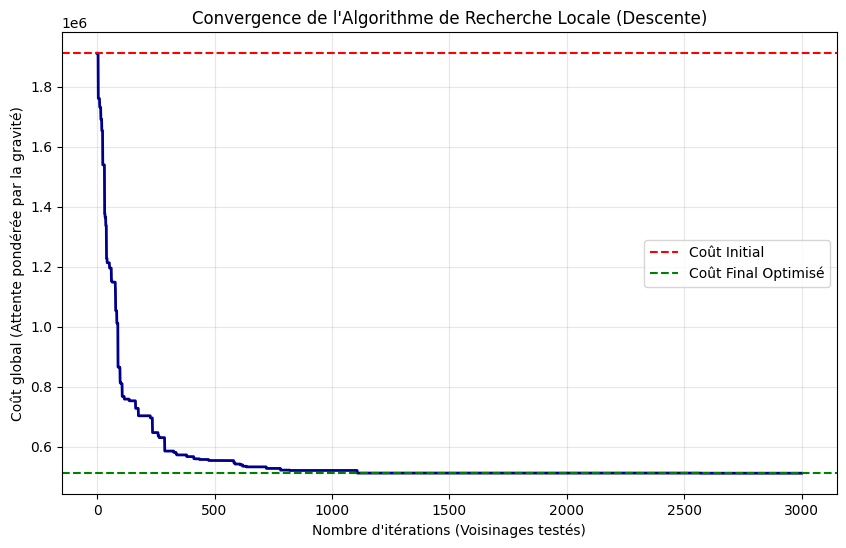

In [86]:
tracer_courbe_convergence(historique)

# VOISINNAGE V2 : pt de départ = liste aléatoire

In [87]:
# on supprime les P et D de la base :
df = df[~df["_diagnostic_code_ccmu"].isin(["P", "D"])].copy()


In [88]:
def get_random_initial_batch(df_raw, start_time, end_time):
    df = df_raw.copy()
    mask = (df["datetime_arrivee"] >= start_time) & (df["datetime_arrivee"] < end_time)
    df = df[mask].copy()
    
    # Poids CCMU (rappel: tu as déjà supprimé P et D au-dessus)
    weight_map = {"5": 50, "4": 40, "3": 30, "2": 20, "1": 10}
    df["weight_val"] = df["_diagnostic_code_ccmu"].astype(str).str.strip().map(weight_map)
    df = df[df["weight_val"] > 0].copy()
    
    # Durée fixée (Graine 42 pour reproductibilité)
    np.random.seed(42) 
    durations = np.random.normal(loc=90, scale=20, size=len(df))
    df['duree_simulee'] = np.maximum(durations, 10)
    
    # --- LA DIFFÉRENCE EST ICI ---
    # Mélange aléatoire total de la liste de patients
    df_random = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df_random.to_dict('records')

In [89]:
# On définit le créneau
START = pd.to_datetime("2016-07-01 20:00:00")
END = pd.to_datetime("2016-07-01 23:59:59")

# On extrait la liste aléatoire
sequence_aleatoire = get_random_initial_batch(df, START, END)

# On évalue le coût de ce joyeux bazar
cout_initial_alea = evaluer_sequence(sequence_aleatoire)
print(f"Coût de la solution initiale (Aléatoire) : {cout_initial_alea:,.2f}")

Coût de la solution initiale (Aléatoire) : 2,124,130.25


In [90]:
# Lancement de la descente sur notre liste aléatoire
best_seq_alea, historique_alea = recherche_locale_descente(sequence_aleatoire, iterations=3000, nb_box=10)

--- Lancement de l'Algorithme par Voisinage (Descente) ---
Itération 0 | Meilleur coût : 1,975,286.72
Itération 500 | Meilleur coût : 570,488.41
Itération 1000 | Meilleur coût : 524,830.67
Itération 1500 | Meilleur coût : 516,612.70
Itération 2000 | Meilleur coût : 507,495.95
Itération 2500 | Meilleur coût : 505,846.43
Coût final : 502,929.26 


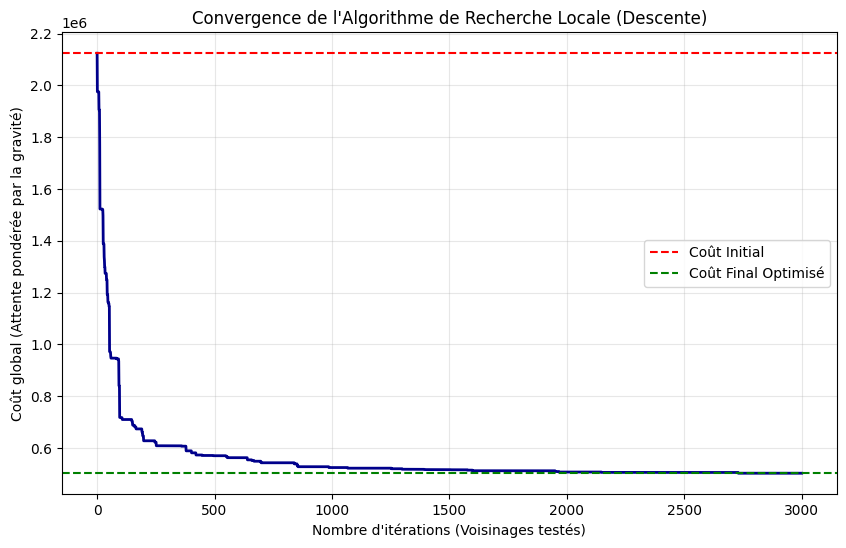

In [91]:
# On trace la courbe d'apprentissage propre à la V2
tracer_courbe_convergence(historique_alea)

Commentaires finaux : 
- les deux algos marchent niquel, au final on retrouve quasiment le même coût
- donc, on peut partir d'une liste aléatoire et se retrouver avec une liste bien triée, ce qui évite d'utiliser delai_total_calc, qui est vrmt pas ouf
- MAIS on utilise une durée simulée, qui suit une loi normale, donc rsque de sur-optimisation par rapport à des durées de soins estimées…?